In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve
)
import pickle
import re
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully!")
print(f"Python libraries ready for training")

✓ Libraries imported successfully!
Python libraries ready for training


# DATA LOADING & EXPLORATION


In [26]:
def load_hate_speech_data(filepath='labeled_data.csv'):

    try:
        # Read CSV
        df = pd.read_csv(filepath)
        print(f"✓ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"\nColumns: {df.columns.tolist()}")
        return df
    except FileNotFoundError:
        print(f"❌ File not found: {filepath}")
        print("\nPlease ensure the dataset file is in the same directory.")
        return None


print("\n" + "="*70)
print("LOADING HATE SPEECH & OFFENSIVE LANGUAGE DATASET")
print("="*70)

# Load data
df = load_hate_speech_data('labeled_data.csv')

if df is None:
    print("\n⚠ Cannot proceed without data. Please check file path.")
    exit()

# Display basic info
print(f"\n📊 Dataset Overview:")
print(df.head(10))

print(f"\n📈 Original Class Distribution:")
print(df['class'].value_counts().sort_index())
print("\nClass meanings:")
print("  0 = hate speech")
print("  1 = offensive language")
print("  2 = neither")



LOADING HATE SPEECH & OFFENSIVE LANGUAGE DATASET
✓ Data loaded: 24783 rows, 7 columns

Columns: ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

📊 Dataset Overview:
   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   
5           5      3            1                   2        0      1   
6           6      3            0                   3        0      1   
7           7      3            0                   3        0      1   
8           8      3            0                   3        0      1   
9           9      3            1                   2        0

# BINARY LABEL CONVERSION


In [27]:
print("\n" + "="*70)
print("CONVERTING TO BINARY CLASSIFICATION")
print("="*70)

# Convert 3-class to binary
# class 0 (hate) and 1 (offensive) → 1 (foul)
# class 2 (neither) → 0 (proper)
df['label'] = df['class'].apply(lambda x: 0 if x == 2 else 1)

print(f"\n✓ Binary labels created:")
print(f"  0 (Proper/Neither) = {(df['label'] == 0).sum()} tweets")
print(f"  1 (Foul/Offensive) = {(df['label'] == 1).sum()} tweets")

print(f"\n📊 Class Balance:")
class_dist = df['label'].value_counts(normalize=True)
print(f"  Proper: {class_dist[0]:.2%}")
print(f"  Foul:   {class_dist[1]:.2%}")


CONVERTING TO BINARY CLASSIFICATION

✓ Binary labels created:
  0 (Proper/Neither) = 4163 tweets
  1 (Foul/Offensive) = 20620 tweets

📊 Class Balance:
  Proper: 16.80%
  Foul:   83.20%


Show examples


In [28]:
print(f"\n Sample Proper Tweets (label=0):")
proper_samples = df[df['label'] == 0]['tweet'].head(3)
for i, tweet in enumerate(proper_samples, 1):
    print(f"  {i}. {tweet[:80]}...")

print(f"\n Sample Foul Tweets (label=1):")
foul_samples = df[df['label'] == 1]['tweet'].head(3)
for i, tweet in enumerate(foul_samples, 1):
    print(f"  {i}. {tweet[:80]}...")


 Sample Proper Tweets (label=0):
  1. !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your h...
  2. " momma said no pussy cats inside my doghouse "...
  3. "@Addicted2Guys: -SimplyAddictedToGuys http://t.co/1jL4hi8ZMF" woof woof hot sca...

 Sample Foul Tweets (label=1):
  1. !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st pl...
  2. !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and s...
  3. !!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny...


# TEXT PREPROCESSING


In [29]:
def preprocess_tweet(text):
    """
    Clean and preprocess tweet text
    """
    if pd.isna(text):
        return ""

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove user mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Remove RT (retweet indicator)
    text = re.sub(r'\brt\b', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove special characters and punctuation (keep only letters, numbers, and spaces)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    return text

In [30]:
print("\n" + "="*70)
print("TEXT PREPROCESSING")
print("="*70)

df['text_clean'] = df['tweet'].apply(preprocess_tweet)

print(f"✓ Text preprocessing complete")
print(f"\n📝 Before vs After Cleaning:")
for i in range(3):
    print(f"\nOriginal:  {df['tweet'].iloc[i][:70]}...")
    print(f"Cleaned:   {df['text_clean'].iloc[i][:70]}...")


TEXT PREPROCESSING
✓ Text preprocessing complete

📝 Before vs After Cleaning:

Original:  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning...
Cleaned:     as a woman you shouldnt complain about cleaning up your house amp as...

Original:  !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in ...
Cleaned:     boy dats coldtyga dwn bad for cuffin dat hoe in the 1st place...

Original:  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a b...
Cleaned:    dawg  you ever fuck a bitch and she start to cry you be confused as s...


# TRAIN-TEST SPLIT


In [31]:
print("\n" + "="*70)
print("TRAIN-TEST SPLIT (80/20)")
print("="*70)

X = df['text_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class balance
)

print(f"✓ Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"✓ Test set:     {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nTrain set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())


TRAIN-TEST SPLIT (80/20)
✓ Training set: 19826 samples (80.0%)
✓ Test set:     4957 samples (20.0%)

Train set class distribution:
label
1    16496
0     3330
Name: count, dtype: int64

Test set class distribution:
label
1    4124
0     833
Name: count, dtype: int64


# FEATURE ENGINEERING - TF-IDF WITH BIGRAMS


In [32]:
print("\n" + "="*70)
print("FEATURE ENGINEERING - TF-IDF")
print("="*70)

print("\n📚 What is TF-IDF?")
print("  TF (Term Frequency): How often a word appears in a tweet")
print("  IDF (Inverse Document Frequency): How unique/important the word is")
print("  TF-IDF = TF × IDF (higher score = more important word)")

print("\n📚 What are N-grams?")
print("  Unigrams (1-gram): Single words ['bad', 'tweet']")
print("  Bigrams (2-gram): Word pairs ['bad tweet', 'very offensive']")
print("  → Bigrams capture context better!")

vectorizer = TfidfVectorizer(
    max_features=5000,      # Keep top 5000 most important features
    ngram_range=(1, 2),     # Use both unigrams AND bigrams
    min_df=2,               # Word must appear in at least 2 tweets
    max_df=0.8,             # Ignore words in >80% of tweets (too common)
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{1,}',
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=True       # Use log scaling for term frequency
)

print("\n🔄 Fitting vectorizer on training data...")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"\n✓ TF-IDF vectorization complete!")
print(f"  Vocabulary size: {len(vectorizer.vocabulary_)} features")
print(f"  Training matrix: {X_train_tfidf.shape}")
print(f"  Test matrix:     {X_test_tfidf.shape}")

# Show sample features (including bigrams)
feature_names = vectorizer.get_feature_names_out()
print(f"\n📝 Sample Features (Unigrams + Bigrams):")
sample_features = np.random.choice(feature_names, 20, replace=False)
for i, feat in enumerate(sample_features, 1):
    print(f"  {i:2d}. '{feat}'")



FEATURE ENGINEERING - TF-IDF

📚 What is TF-IDF?
  TF (Term Frequency): How often a word appears in a tweet
  IDF (Inverse Document Frequency): How unique/important the word is
  TF-IDF = TF × IDF (higher score = more important word)

📚 What are N-grams?
  Unigrams (1-gram): Single words ['bad', 'tweet']
  Bigrams (2-gram): Word pairs ['bad tweet', 'very offensive']
  → Bigrams capture context better!

🔄 Fitting vectorizer on training data...

✓ TF-IDF vectorization complete!
  Vocabulary size: 5000 features
  Training matrix: (19826, 5000)
  Test matrix:     (4957, 5000)

📝 Sample Features (Unigrams + Bigrams):
   1. 'gun'
   2. 'me about'
   3. 'a niggah'
   4. 'dumb bitches'
   5. 'bitches to'
   6. 'yankees'
   7. 'fav'
   8. 'of trash'
   9. 'past'
  10. 'you been'
  11. 'hoes man'
  12. 'nice to'
  13. 'his'
  14. 'worried about'
  15. 'thing that'
  16. 'leave'
  17. 'am i'
  18. 'radio'
  19. 'draft'
  20. 'ho'


# MODEL TRAINING


In [33]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',  # Handle class imbalance
        solver='liblinear'
    ),
    'SVM': LinearSVC(
        max_iter=5000,
        random_state=42,
        class_weight='balanced',
        dual=False
    ),
    'Naive Bayes': MultinomialNB(
        alpha=0.1  # Laplace smoothing
    )
}

In [34]:
# Store results
trained_models = {}
results = []

for name, model in models.items():
    print(f"\n{'='*70}")
    print(f"🤖 Training: {name}")
    print(f"{'='*70}")

    # Train
    print(f"  ⏳ Fitting model...")
    model.fit(X_train_tfidf, y_train)

    # Predictions
    y_pred = model.predict(X_test_tfidf)

    # Get probabilities for AUC metrics
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_proba = model.decision_function(X_test_tfidf)
    else:
        y_proba = y_pred

    # Store model
    trained_models[name] = model
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'F1_Macro': f1_macro,
        'F1_Weighted': f1_weighted,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'y_pred': y_pred,
        'y_proba': y_proba
    })

    print(f"  ✓ Training complete!")
    print(f"  📊 Quick Results:")
    print(f"     Accuracy:  {acc:.4f}")
    print(f"     Precision: {prec:.4f}")
    print(f"     Recall:    {rec:.4f}")
    print(f"     F1 Score:  {f1:.4f}")


🤖 Training: Logistic Regression
  ⏳ Fitting model...
  ✓ Training complete!
  📊 Quick Results:
     Accuracy:  0.9330
     Precision: 0.9877
     Recall:    0.9311
     F1 Score:  0.9586

🤖 Training: SVM
  ⏳ Fitting model...
  ✓ Training complete!
  📊 Quick Results:
     Accuracy:  0.9417
     Precision: 0.9846
     Recall:    0.9447
     F1 Score:  0.9642

🤖 Training: Naive Bayes
  ⏳ Fitting model...
  ✓ Training complete!
  📊 Quick Results:
     Accuracy:  0.9126
     Precision: 0.9150
     Recall:    0.9867
     F1 Score:  0.9495


# MODEL COMPARISON



In [35]:
print("MODEL COMPARISON - ALL METRICS")
results_df = pd.DataFrame(results)
display_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'F1_Macro', 'F1_Weighted', 'ROC-AUC', 'PR-AUC']
print("\n" + results_df[display_cols].to_string(index=False))

# Find best model
best_idx = results_df['F1'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"\n🏆 Best Model (by F1 Score): {best_model_name}")


MODEL COMPARISON - ALL METRICS

              Model  Accuracy  Precision   Recall       F1  F1_Macro  F1_Weighted  ROC-AUC   PR-AUC
Logistic Regression  0.933024   0.987654 0.931135 0.958562  0.892005     0.936193 0.979045 0.995589
                SVM  0.941699   0.984584 0.944714 0.964237  0.903286     0.943752 0.977187 0.994921
        Naive Bayes  0.912649   0.914999 0.986663 0.949481  0.813534     0.903790 0.966787 0.993001

🏆 Best Model (by F1 Score): SVM


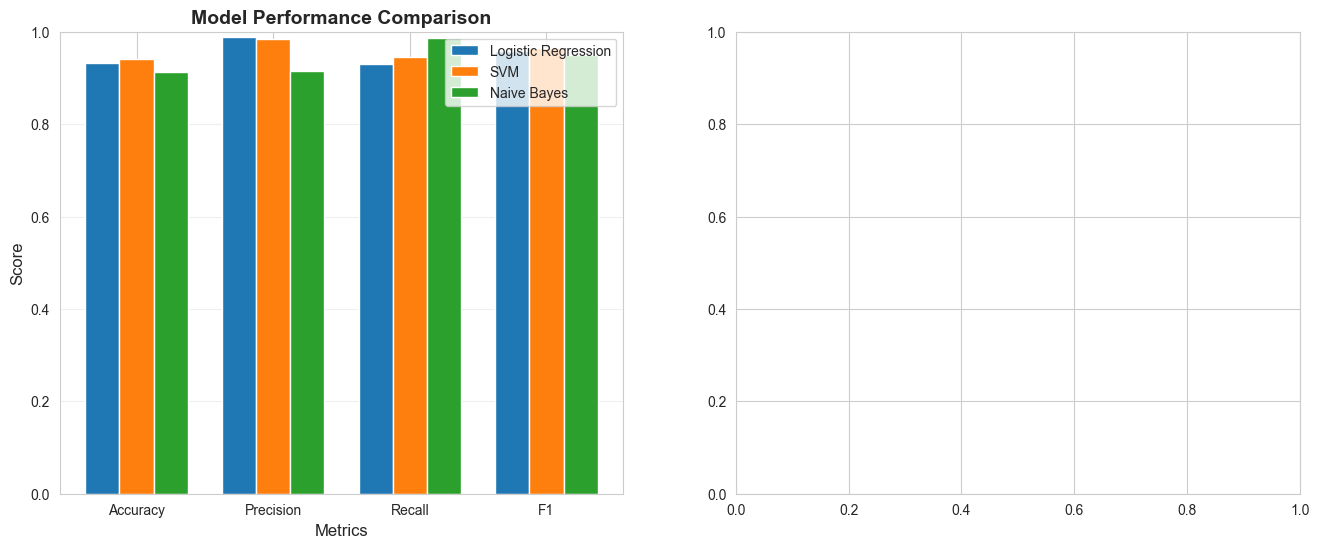

In [36]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Basic metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.25

for i, (idx, row) in enumerate(results_df.iterrows()):
    offset = (i - 1) * width
    axes[0].bar(x + offset, [row[m] for m in metrics], width, label=row['Model'])

axes[0].set_xlabel('Metrics', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)



✓ Comparison chart saved: 'model_comparison.png'


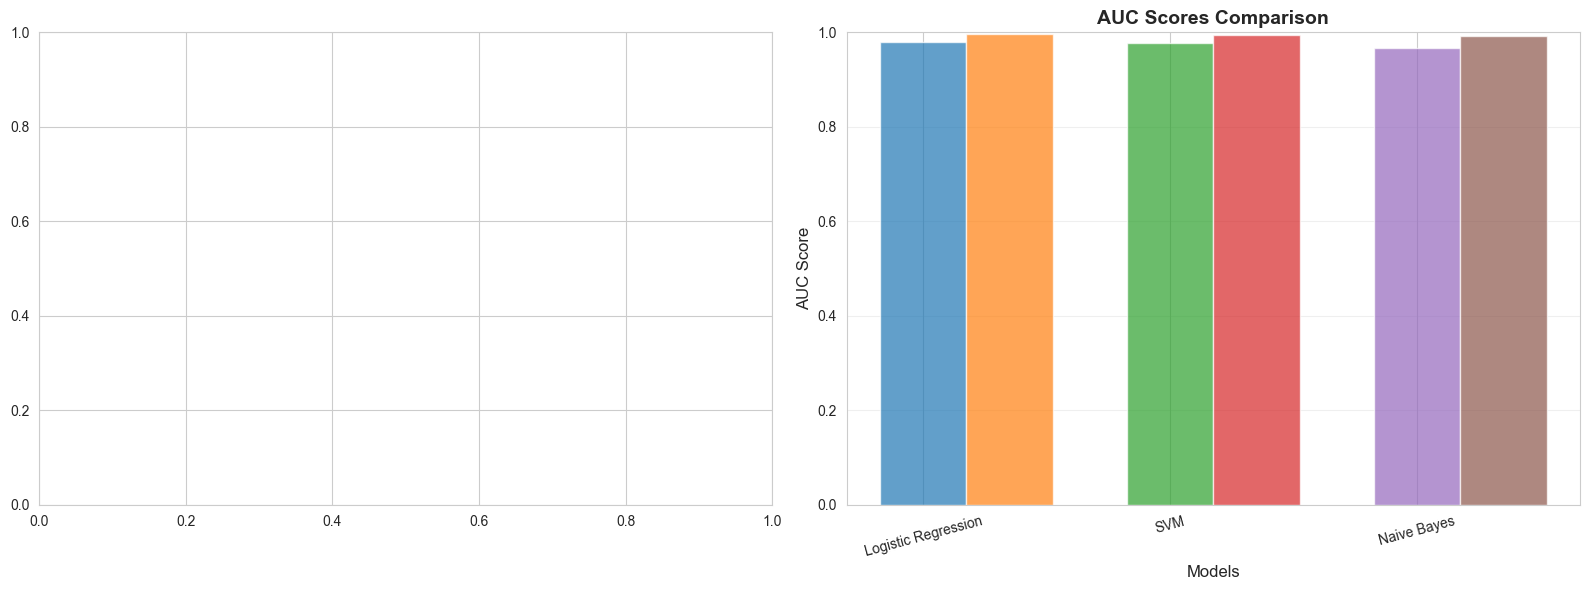

In [37]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# AUC metrics
for i, (idx, row) in enumerate(results_df.iterrows()):
    axes[1].bar(i, row['ROC-AUC'], 0.35, label=f"{row['Model']} (ROC)", alpha=0.7)
    axes[1].bar(i + 0.35, row['PR-AUC'], 0.35, label=f"{row['Model']} (PR)", alpha=0.7)

axes[1].set_xlabel('Models', fontsize=12)
axes[1].set_ylabel('AUC Score', fontsize=12)
axes[1].set_title('AUC Scores Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels(results_df['Model'], rotation=15)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Comparison chart saved: 'model_comparison.png'")

# DETAILED EVALUATION - BEST MODEL


In [38]:
print(f"DETAILED EVALUATION - {best_model_name.upper()}")
best_model = trained_models[best_model_name]
best_result = results[best_idx]

# Detailed metrics
print(f"\n📊 Complete Metrics:")
print(f"  Accuracy:        {best_result['Accuracy']:.4f}")
print(f"  Precision:       {best_result['Precision']:.4f}")
print(f"  Recall:          {best_result['Recall']:.4f}")
print(f"  F1 Score:        {best_result['F1']:.4f}")
print(f"  F1 Macro:        {best_result['F1_Macro']:.4f}")
print(f"  F1 Weighted:     {best_result['F1_Weighted']:.4f}")
print(f"  ROC-AUC:         {best_result['ROC-AUC']:.4f}")
print(f"  PR-AUC:          {best_result['PR-AUC']:.4f}")

DETAILED EVALUATION - SVM

📊 Complete Metrics:
  Accuracy:        0.9417
  Precision:       0.9846
  Recall:          0.9447
  F1 Score:        0.9642
  F1 Macro:        0.9033
  F1 Weighted:     0.9438
  ROC-AUC:         0.9772
  PR-AUC:          0.9949



📋 Classification Report:
              precision    recall  f1-score   support

      Proper     0.7720    0.9268    0.8423       833
        Foul     0.9846    0.9447    0.9642      4124

    accuracy                         0.9417      4957
   macro avg     0.8783    0.9357    0.9033      4957
weighted avg     0.9489    0.9417    0.9438      4957


📊 Confusion Matrix:
                Predicted
              Proper  Foul
Actual Proper    772     61
       Foul      228   3896

✓ Evaluation charts saved: 'detailed_evaluation.png'


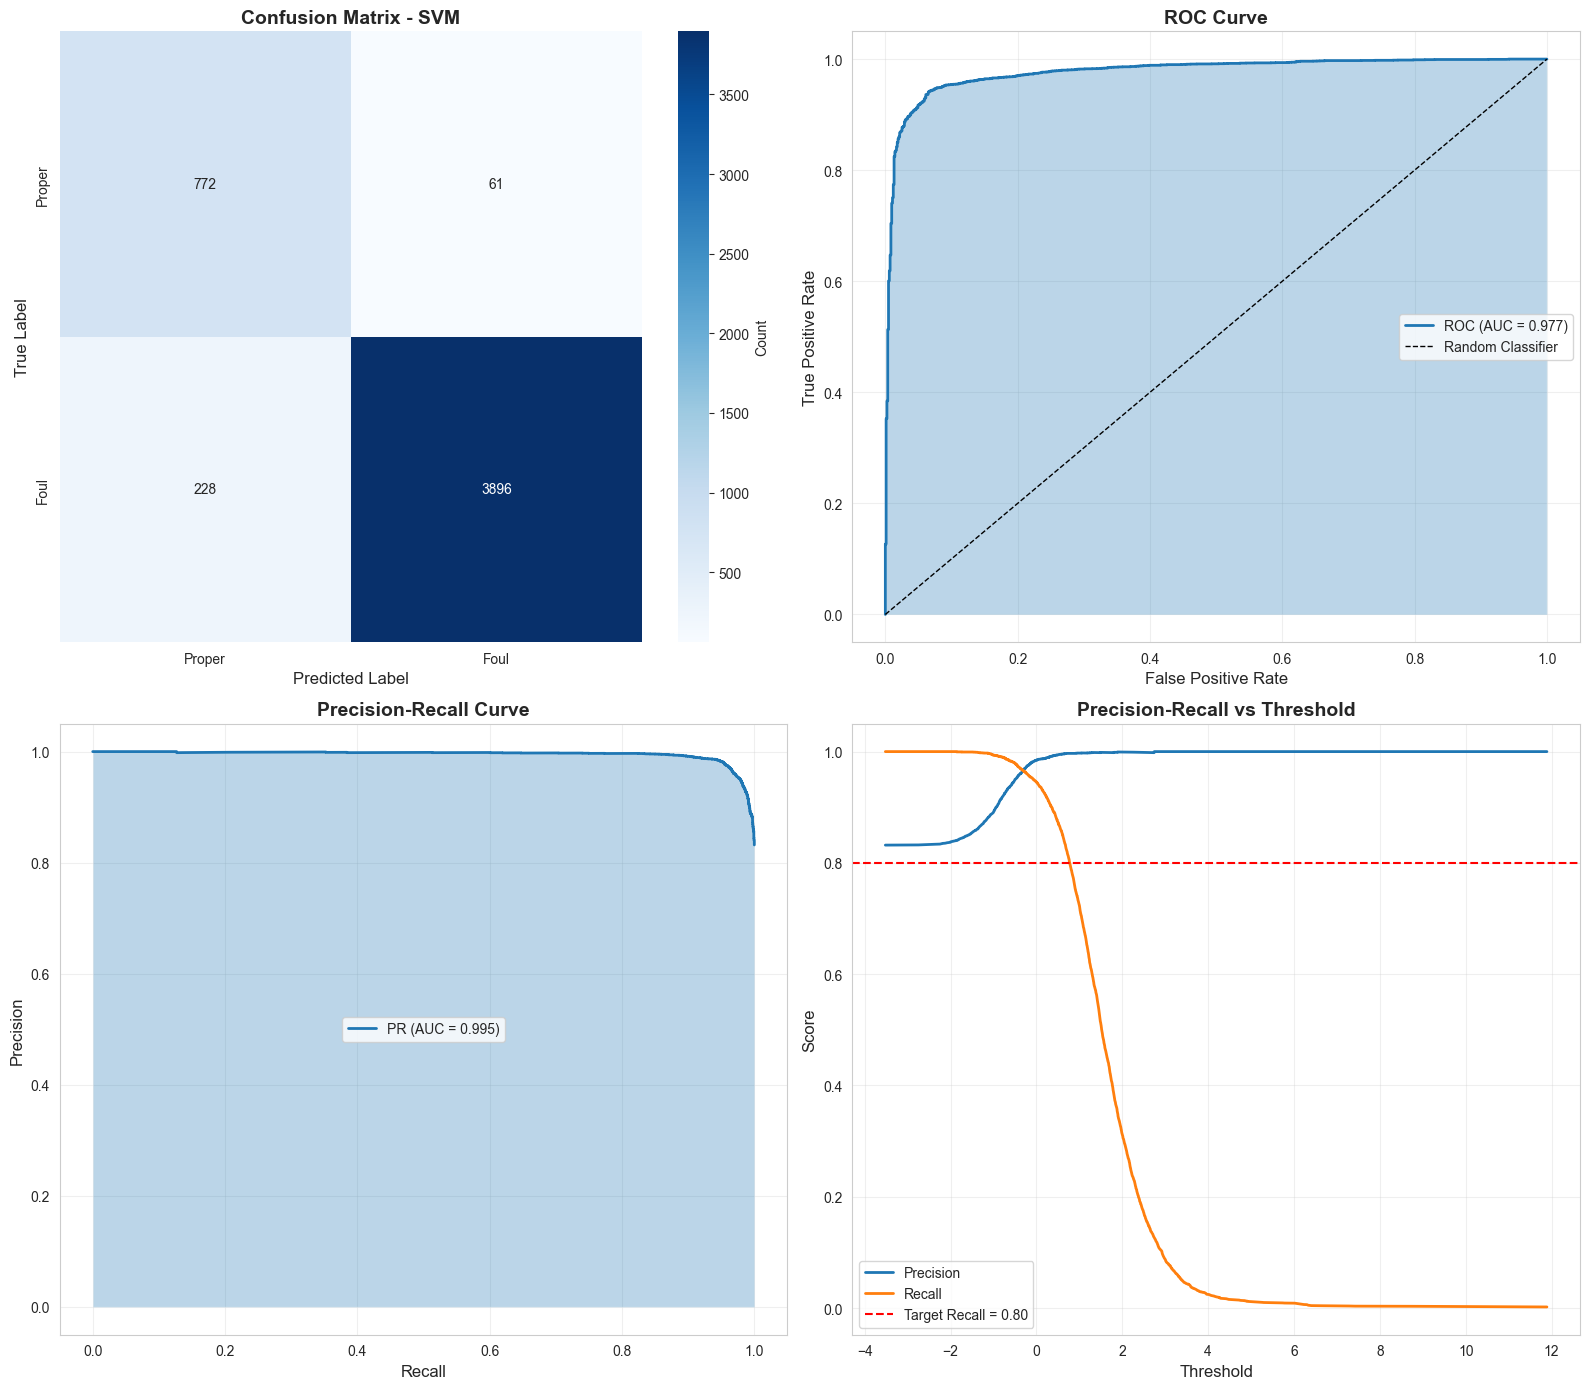

In [39]:
# Classification report
print(f"\n📋 Classification Report:")
print(classification_report(y_test, best_result['y_pred'],
                          target_names=['Proper', 'Foul'],
                          digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, best_result['y_pred'])
print(f"\n📊 Confusion Matrix:")
print(f"                Predicted")
print(f"              Proper  Foul")
print(f"Actual Proper  {cm[0][0]:5d}  {cm[0][1]:5d}")
print(f"       Foul    {cm[1][0]:5d}  {cm[1][1]:5d}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Proper', 'Foul'],
            yticklabels=['Proper', 'Foul'],
            cbar_kws={'label': 'Count'})
axes[0, 0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('True Label', fontsize=12)
axes[0, 0].set_xlabel('Predicted Label', fontsize=12)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_result['y_proba'])
axes[0, 1].plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {best_result["ROC-AUC"]:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0, 1].fill_between(fpr, tpr, alpha=0.3)
axes[0, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, best_result['y_proba'])
axes[1, 0].plot(recall, precision, linewidth=2, label=f'PR (AUC = {best_result["PR-AUC"]:.3f})')
axes[1, 0].fill_between(recall, precision, alpha=0.3)
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 4. Precision-Recall vs Threshold
axes[1, 1].plot(thresholds, precision[:-1], label='Precision', linewidth=2)
axes[1, 1].plot(thresholds, recall[:-1], label='Recall', linewidth=2)
axes[1, 1].axhline(y=0.80, color='r', linestyle='--', linewidth=1.5, label='Target Recall = 0.80')
axes[1, 1].set_xlabel('Threshold', fontsize=12)
axes[1, 1].set_ylabel('Score', fontsize=12)
axes[1, 1].set_title('Precision-Recall vs Threshold', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('detailed_evaluation.png', dpi=300, bbox_inches='tight')
print("\n✓ Evaluation charts saved: 'detailed_evaluation.png'")

HRESHOLD TUNING (RECALL ≥ 0.80)


In [18]:
print("THRESHOLD TUNING FOR RECALL ≥ 0.80")
print("\n📚 Why tune threshold?")
print("  Default threshold = 0.5 (if P(foul) > 0.5 → predict foul)")
print("  Lower threshold → catch more foul tweets (higher recall)")
print("  But → more false alarms (lower precision)")
print("  Goal: Find best precision while maintaining recall ≥ 0.80")


THRESHOLD TUNING FOR RECALL ≥ 0.80

📚 Why tune threshold?
  Default threshold = 0.5 (if P(foul) > 0.5 → predict foul)
  Lower threshold → catch more foul tweets (higher recall)
  But → more false alarms (lower precision)
  Goal: Find best precision while maintaining recall ≥ 0.80


In [19]:
# Calculate precision-recall at different thresholds
precision_vals, recall_vals, threshold_vals = precision_recall_curve(
    y_test, best_result['y_proba']
)

In [20]:
# Find threshold for Recall >= 0.80
target_recall = 0.80
valid_idx = np.where(recall_vals >= target_recall)[0]

if len(valid_idx) > 0:
    # Get threshold with best precision at target recall
    best_idx = valid_idx[np.argmax(precision_vals[valid_idx])]
    optimal_threshold = threshold_vals[best_idx] if best_idx < len(threshold_vals) else 0.5
    optimal_precision = precision_vals[best_idx]
    optimal_recall = recall_vals[best_idx]

    print(f"\n✓ Optimal threshold found!")
    print(f"  Threshold:  {optimal_threshold:.4f}")
    print(f"  Precision:  {optimal_precision:.4f}")
    print(f"  Recall:     {optimal_recall:.4f}")

    # Apply tuned threshold
    if hasattr(best_model, 'predict_proba'):
        y_proba_tuned = best_model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_proba_tuned = best_model.decision_function(X_test_tfidf)

    y_pred_tuned = (y_proba_tuned >= optimal_threshold).astype(int)

    print(f"\n📊 Performance with tuned threshold:")
    print(f"  Accuracy:   {accuracy_score(y_test, y_pred_tuned):.4f}")
    print(f"  Precision:  {precision_score(y_test, y_pred_tuned):.4f}")
    print(f"  Recall:     {recall_score(y_test, y_pred_tuned):.4f}")
    print(f"  F1 Score:   {f1_score(y_test, y_pred_tuned):.4f}")

    print(f"\n📊 Comparison (Default vs Tuned):")
    print(f"  Metric      Default   Tuned")
    print(f"  Threshold   0.5000    {optimal_threshold:.4f}")
    print(f"  Precision   {best_result['Precision']:.4f}    {precision_score(y_test, y_pred_tuned):.4f}")
    print(f"  Recall      {best_result['Recall']:.4f}    {recall_score(y_test, y_pred_tuned):.4f}")
    print(f"  F1 Score    {best_result['F1']:.4f}    {f1_score(y_test, y_pred_tuned):.4f}")
else:
    print("\n⚠ Could not achieve Recall >= 0.80 with any threshold")
    optimal_threshold = 0.5
    print(f"  Using default threshold: {optimal_threshold}")


✓ Optimal threshold found!
  Threshold:  0.7804
  Precision:  0.9973
  Recall:     0.8026

📊 Performance with tuned threshold:
  Accuracy:   0.8340
  Precision:  0.9973
  Recall:     0.8026
  F1 Score:   0.8894

📊 Comparison (Default vs Tuned):
  Metric      Default   Tuned
  Threshold   0.5000    0.7804
  Precision   0.9859    0.9973
  Recall      0.9479    0.8026
  F1 Score    0.9665    0.8894


# FAILURE ANALYSIS


In [21]:
# False Positives (predicted foul, actually proper)
fp_idx = np.where((best_result['y_pred'] == 1) & (y_test.values == 0))[0]
print(f"\n❌ False Positives: {len(fp_idx)} ({len(fp_idx)/len(y_test)*100:.1f}%)")
print(f"   (Predicted as Foul but actually Proper)")

if len(fp_idx) > 0:
    print(f"\n   Sample False Positives:")
    for i, idx in enumerate(fp_idx[:5], 1):
        tweet = X_test.iloc[idx]
        print(f"   {i}. '{tweet[:80]}...'")

# False Negatives (predicted proper, actually foul)
fn_idx = np.where((best_result['y_pred'] == 0) & (y_test.values == 1))[0]
print(f"\n❌ False Negatives: {len(fn_idx)} ({len(fn_idx)/len(y_test)*100:.1f}%)")
print(f"   (Predicted as Proper but actually Foul)")

if len(fn_idx) > 0:
    print(f"\n   Sample False Negatives:")
    for i, idx in enumerate(fn_idx[:5], 1):
        tweet = X_test.iloc[idx]
        print(f"   {i}. '{tweet[:80]}...'")


❌ False Positives: 56 (1.1%)
   (Predicted as Foul but actually Proper)

   Sample False Positives:
   1. 'but rich is a light skin coon. so it's expected....'
   2. 'on that 4th down incompletion, both the slants looked like better options. shame...'
   3. 'my shift won't be over no time so in the mean time im doing what i have to go to...'
   4. 'no girls no hoes just me myself and i...'
   5. 'up early then a bitch driving to denton omg can i move already...'

❌ False Negatives: 215 (4.3%)
   (Predicted as Proper but actually Foul)

   Sample False Negatives:
   1. ': lol i don't need halloween to dress like a ho. i know myself. everyday is anot...'
   2. 'already kno nicca...'
   3. 'charlie not fukin around in austin.. every week somebody getting kicked off the ...'
   4. 'produced by yung &#128293;&#128293; bouta drop dis hoe...'
   5. 'fear the queer...'


# SAVE MODEL ARTIFACTS


In [22]:
# Save best model
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"✓ Model saved: 'model.pkl' ({best_model_name})")

# Save vectorizer
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
print(f"✓ Vectorizer saved: 'vectorizer.pkl'")

# Save optimal threshold
with open('threshold.pkl', 'wb') as f:
    pickle.dump(optimal_threshold, f)
print(f"✓ Threshold saved: 'threshold.pkl' ({optimal_threshold:.4f})")

# Save metadata
metadata = {
    'best_model': best_model_name,
    'threshold': optimal_threshold,
    'accuracy': best_result['Accuracy'],
    'precision': best_result['Precision'],
    'recall': best_result['Recall'],
    'f1_score': best_result['F1'],
    'roc_auc': best_result['ROC-AUC'],
    'pr_auc': best_result['PR-AUC'],
    'features': len(vectorizer.vocabulary_),
    'train_samples': len(X_train),
    'test_samples': len(X_test)
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print(f"✓ Metadata saved: 'model_metadata.pkl'")


✓ Model saved: 'model.pkl' (SVM)
✓ Vectorizer saved: 'vectorizer.pkl'
✓ Threshold saved: 'threshold.pkl' (0.7804)
✓ Metadata saved: 'model_metadata.pkl'


# SUMMARY

In [23]:
print("✅ TRAINING COMPLETE!")
print(f"\n🏆 Best Model: {best_model_name}")
print(f"\n📊 Final Performance:")
print(f"   Accuracy:  {best_result['Accuracy']:.4f}")
print(f"   Precision: {best_result['Precision']:.4f}")
print(f"   Recall:    {best_result['Recall']:.4f}")
print(f"   F1 Score:  {best_result['F1']:.4f}")
print(f"   ROC-AUC:   {best_result['ROC-AUC']:.4f}")

print(f"\n💾 Files Created:")
print(f"   ✓ model.pkl              - Trained {best_model_name}")
print(f"   ✓ vectorizer.pkl         - TF-IDF vectorizer")
print(f"   ✓ threshold.pkl          - Optimal threshold ({optimal_threshold:.4f})")
print(f"   ✓ model_metadata.pkl     - Model information")
print(f"   ✓ model_comparison.png   - Performance comparison chart")
print(f"   ✓ detailed_evaluation.png - Evaluation metrics visualization")

✅ TRAINING COMPLETE!

🏆 Best Model: SVM

📊 Final Performance:
   Accuracy:  0.9453
   Precision: 0.9859
   Recall:    0.9479
   F1 Score:  0.9665
   ROC-AUC:   0.9803

💾 Files Created:
   ✓ model.pkl              - Trained SVM
   ✓ vectorizer.pkl         - TF-IDF vectorizer
   ✓ threshold.pkl          - Optimal threshold (0.7804)
   ✓ model_metadata.pkl     - Model information
   ✓ model_comparison.png   - Performance comparison chart
   ✓ detailed_evaluation.png - Evaluation metrics visualization
